# Day 6 — Promotion Gap Risk & Retention Opportunity Analysis

## Project: Career Progression and Promotion Gap Analysis

### Main Goal

Turn the career progression and clustering results into an **explainable HR decision-support framework**.

We will identify employees who show signals of:

- Promotion stagnation
- Long time in the current role
- Limited development
- Career progression concerns

Then we will create:

1. Promotion Gap Risk Score
2. Risk Level
3. Retention Opportunity Index
4. Recommended HR Action

> **Important:** These are analytical decision-support indicators, not predictions or proof that an employee will leave.


## 1. Output Folder Setup

This notebook automatically creates folders for:

```text
outputs/
├── figures/
├── tables/
├── reports/
└── models/
```

It will save important charts, tables, and text reports automatically.


In [1]:
from pathlib import Path
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

# Project root is one level above the notebook's nb/ folder.
PROJECT_ROOT = Path("..")

OUTPUTS = PROJECT_ROOT / "outputs"
FIGURES = OUTPUTS / "figures"
TABLES = OUTPUTS / "tables"
REPORTS = OUTPUTS / "reports"
MODELS = OUTPUTS / "models"

for folder in [OUTPUTS, FIGURES, TABLES, REPORTS, MODELS]:
    folder.mkdir(parents=True, exist_ok=True)

print("Output folders are ready.")


Output folders are ready.


## 2. Load Data

We first try to load the final clustering dataset.

If it is not available, we fall back to the feature-engineered dataset and explain that the cluster column must then be supplied from Day 5.

Expected files:

- `data/feature_engineered_palo_alto.csv`
- optionally `data/clustered_palo_alto.csv`

> If your Day 5 notebook uses another filename, update the path below.


In [2]:
clustered_path = PROJECT_ROOT / "data" / "clustered_palo_alto.csv"
feature_path = PROJECT_ROOT / "data" / "feature_engineered_palo_alto.csv"

if clustered_path.exists():
    df = pd.read_csv(clustered_path)
    print(f"Loaded clustered dataset: {clustered_path}")
elif feature_path.exists():
    df = pd.read_csv(feature_path)
    print(f"Loaded feature-engineered dataset: {feature_path}")
    print("Note: CareerCluster was not found in the preferred clustered file path.")
else:
    raise FileNotFoundError(
        "Could not find the Day 5 clustered dataset or Day 4 feature-engineered dataset."
    )

print("Shape:", df.shape)
display(df.head())


Loaded feature-engineered dataset: ../data/feature_engineered_palo_alto.csv
Note: CareerCluster was not found in the preferred clustered file path.
Shape: (1470, 38)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PromotionGapRatio,RoleStagnationRatio,ManagerStabilityRatio,CareerStage,PromotionGapGroup,RoleDurationGroup,TrainingGroup
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Yes,11,3,1,0,8,0,1,6,4,0,5,0.000,0.666667,0.833333,Established,Recent Promotion,Established,No Training
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,No,23,4,4,1,10,3,3,10,7,1,7,0.100,0.700000,0.700000,Established,Recent Promotion,Long Time in Role,Moderate Training
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Yes,15,3,2,0,7,3,3,0,0,0,0,0.000,0.000000,0.000000,Early Career,Recent Promotion,New in Role,Moderate Training
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Yes,11,3,3,0,8,3,3,8,7,3,0,0.375,0.875000,0.000000,Established,Moderate Gap,Long Time in Role,Moderate Training
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,No,12,3,4,1,6,3,3,2,2,2,2,1.000,1.000000,1.000000,Early Career,Moderate Gap,New in Role,Moderate Training


## 3. Basic Validation

Before creating risk indicators, verify that the important career fields are present.


In [3]:
required_columns = [
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager",
    "TrainingTimesLastYear",
    "JobLevel",
    "PerformanceRating",
    "JobSatisfaction",
    "Department",
    "JobRole",
    "Attrition"
]

missing_required = [col for col in required_columns if col not in df.columns]

if missing_required:
    print("Missing required columns:", missing_required)
else:
    print("All required career/risk columns are available.")

print("\nMissing values:")
print(df[required_columns].isnull().sum().sum())

print("\nDuplicate rows:", df.duplicated().sum())


All required career/risk columns are available.

Missing values:
0

Duplicate rows: 0


# 4. Review Career Signals

These variables form the foundation of our career-risk analysis.


In [4]:
career_signal_columns = [
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager",
    "TrainingTimesLastYear",
    "JobLevel",
    "PerformanceRating",
    "JobSatisfaction"
]

display(df[career_signal_columns].describe().T)


,count,mean,std,min,25%,50%,75%,max
YearsAtCompany,1470.0,7.008163,6.126525,0.0,3.0,5.0,9.0,40.0
YearsInCurrentRole,1470.0,4.229252,3.623137,0.0,2.0,3.0,7.0,18.0
YearsSinceLastPromotion,1470.0,2.187755,3.222430,0.0,0.0,1.0,3.0,15.0
YearsWithCurrManager,1470.0,4.123129,3.568136,0.0,2.0,3.0,7.0,17.0
TrainingTimesLastYear,1470.0,2.799320,1.289271,0.0,2.0,3.0,3.0,6.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.0,2.0,3.0,5.0
PerformanceRating,1470.0,3.153741,0.360824,3.0,3.0,3.0,3.0,4.0
JobSatisfaction,1470.0,2.728571,1.102846,1.0,2.0,3.0,4.0,4.0


## 5. Promotion Gap Analysis

First understand the existing promotion-gap distribution before defining a risk score.

We will calculate:

- Count
- Percentage
- Average attrition rate by promotion-gap group


In [5]:
if "PromotionGapGroup" not in df.columns:
    df["PromotionGapGroup"] = pd.cut(
        df["YearsSinceLastPromotion"],
        bins=[-1, 1, 4, np.inf],
        labels=[
            "Recent Promotion",
            "Moderate Gap",
            "Long Promotion Gap"
        ]
    )

promotion_gap_summary = (
    df.groupby("PromotionGapGroup", observed=False)
      .agg(
          Employee_Count=("YearsSinceLastPromotion", "size"),
          Average_Years_Since_Promotion=("YearsSinceLastPromotion", "mean")
      )
      .reset_index()
)

promotion_gap_summary["Percentage"] = (
    promotion_gap_summary["Employee_Count"] / len(df) * 100
).round(2)

display(promotion_gap_summary)

promotion_gap_summary.to_csv(
    TABLES / "promotion_gap_summary.csv",
    index=False
)


,PromotionGapGroup,Employee_Count,Average_Years_Since_Promotion,Percentage
0,Long Promotion Gap,260,8.234615,17.69
1,Moderate Gap,272,2.639706,18.50
2,Recent Promotion,938,0.380597,63.81


## 6. Role Stagnation Analysis

Use `YearsInCurrentRole` and the engineered `RoleStagnationRatio` where available.

We will not assume that a long role duration is automatically negative.


In [6]:
if "RoleDurationGroup" not in df.columns:
    df["RoleDurationGroup"] = pd.cut(
        df["YearsInCurrentRole"],
        bins=[-1, 2, 5, np.inf],
        labels=[
            "New in Role",
            "Established",
            "Long Time in Role"
        ]
    )

role_duration_summary = (
    df.groupby("RoleDurationGroup", observed=False)
      .agg(
          Employee_Count=("YearsInCurrentRole", "size"),
          Average_Years_In_Current_Role=("YearsInCurrentRole", "mean")
      )
      .reset_index()
)

role_duration_summary["Percentage"] = (
    role_duration_summary["Employee_Count"] / len(df) * 100
).round(2)

display(role_duration_summary)

role_duration_summary.to_csv(
    TABLES / "role_duration_summary.csv",
    index=False
)


,RoleDurationGroup,Employee_Count,Average_Years_In_Current_Role,Percentage
0,Established,275,3.640000,18.71
1,Long Time in Role,522,8.457854,35.51
2,New in Role,673,1.190193,45.78


# 7. Build Transparent Promotion Gap Risk Components

We will use a simple, explainable point-based framework.

### Component A — Promotion Gap

- 0 points → Recent/short gap
- 1 point → Moderate gap
- 2 points → Long gap

### Component B — Role Duration

- 0 points → New/short time in role
- 1 point → Established
- 2 points → Long time in role

### Component C — Training

- 0 points → Moderate/high training
- 1 point → Low training
- 2 points → No training

### Component D — Career Cluster

If a Day 5 cluster has been identified as a potential stagnation cluster, it may contribute 2 points.

**Important:** We do not automatically assume a cluster is stagnated. The mapping below must be reviewed using the Day 5 cluster profile.


In [7]:
# Component A: Promotion gap points
df["PromotionGapPoints"] = np.select(
    [
        df["YearsSinceLastPromotion"] <= 1,
        df["YearsSinceLastPromotion"].between(2, 4, inclusive="both"),
        df["YearsSinceLastPromotion"] >= 5
    ],
    [
        0,
        1,
        2
    ],
    default=0
)

# Component B: Role duration points
df["RoleDurationPoints"] = np.select(
    [
        df["YearsInCurrentRole"] <= 2,
        df["YearsInCurrentRole"].between(3, 5, inclusive="both"),
        df["YearsInCurrentRole"] >= 6
    ],
    [
        0,
        1,
        2
    ],
    default=0
)

# Component C: Training points
df["TrainingPoints"] = np.select(
    [
        df["TrainingTimesLastYear"] >= 3,
        df["TrainingTimesLastYear"].between(1, 2, inclusive="both"),
        df["TrainingTimesLastYear"] == 0
    ],
    [
        0,
        1,
        2
    ],
    default=0
)

display(
    df[
        [
            "YearsSinceLastPromotion",
            "PromotionGapPoints",
            "YearsInCurrentRole",
            "RoleDurationPoints",
            "TrainingTimesLastYear",
            "TrainingPoints"
        ]
    ].head(10)
)


,YearsSinceLastPromotion,PromotionGapPoints,YearsInCurrentRole,RoleDurationPoints,TrainingTimesLastYear,TrainingPoints
0,0,0,4,1,0,2
1,1,0,7,2,3,0
2,0,0,0,0,3,0
3,3,1,7,2,3,0
4,2,1,2,0,3,0
5,3,1,7,2,2,1
6,0,0,0,0,3,0
7,0,0,0,0,2,1
8,1,0,7,2,2,1
9,7,2,7,2,3,0


## 8. Career Cluster Risk Component

If `CareerCluster` exists, inspect its profile before assigning any cluster risk points.

For safety, the default is **0 points for every cluster**.

After reviewing Day 5, manually set the cluster(s) that clearly represent career stagnation.


In [8]:
if "CareerCluster" in df.columns:
    cluster_profile = (
        df.groupby("CareerCluster", observed=True)[
            [
                "YearsAtCompany",
                "YearsInCurrentRole",
                "YearsSinceLastPromotion",
                "TrainingTimesLastYear",
                "JobLevel"
            ]
        ]
        .mean()
        .round(2)
    )

    display(cluster_profile)

    # IMPORTANT:
    # Replace [] with the actual stagnation-cluster number(s) after reviewing the profile.
    stagnation_clusters = []

    df["ClusterRiskPoints"] = np.where(
        df["CareerCluster"].isin(stagnation_clusters),
        2,
        0
    )
else:
    print("CareerCluster is not available. ClusterRiskPoints will be 0 until Day 5 output is connected.")
    df["ClusterRiskPoints"] = 0


CareerCluster is not available. ClusterRiskPoints will be 0 until Day 5 output is connected.


# 9. Promotion Gap Risk Score

The score combines the transparent components.

Current maximum:

- Promotion gap = 2
- Role duration = 2
- Training = 2
- Cluster = 2

**Maximum score = 8**

We intentionally keep the score simple and explainable.


In [9]:
df["PromotionGapRiskScore"] = (
    df["PromotionGapPoints"]
    + df["RoleDurationPoints"]
    + df["TrainingPoints"]
    + df["ClusterRiskPoints"]
)

display(
    df[
        [
            "PromotionGapPoints",
            "RoleDurationPoints",
            "TrainingPoints",
            "ClusterRiskPoints",
            "PromotionGapRiskScore"
        ]
    ].head(10)
)

print("Score range:")
print(df["PromotionGapRiskScore"].min(), "to", df["PromotionGapRiskScore"].max())


,PromotionGapPoints,RoleDurationPoints,TrainingPoints,ClusterRiskPoints,PromotionGapRiskScore
0,0,1,2,0,3
1,0,2,0,0,2
2,0,0,0,0,0
3,1,2,0,0,3
4,1,0,0,0,1
5,1,2,1,0,4
6,0,0,0,0,0
7,0,0,1,0,1
8,0,2,1,0,3
9,2,2,0,0,4


Score range:
0 to 6


## 10. Convert Risk Score to Risk Level

Initial transparent thresholds:

- **0–2 → Low**
- **3–5 → Medium**
- **6–8 → High**

These are analytical thresholds, not official HR policy. They can be revised after inspecting the score distribution.


In [10]:
df["PromotionGapRiskLevel"] = pd.cut(
    df["PromotionGapRiskScore"],
    bins=[-1, 2, 5, 8],
    labels=["Low", "Medium", "High"]
)

risk_summary = (
    df["PromotionGapRiskLevel"]
    .value_counts(sort=False)
    .rename_axis("Risk_Level")
    .reset_index(name="Employee_Count")
)

risk_summary["Percentage"] = (
    risk_summary["Employee_Count"] / len(df) * 100
).round(2)

display(risk_summary)

risk_summary.to_csv(
    TABLES / "promotion_gap_risk_summary.csv",
    index=False
)


,Risk_Level,Employee_Count,Percentage
0,Low,1001,68.10
1,Medium,459,31.22
2,High,10,0.68


## 11. Risk Distribution Visualization

Automatically save the chart to `outputs/figures/`.


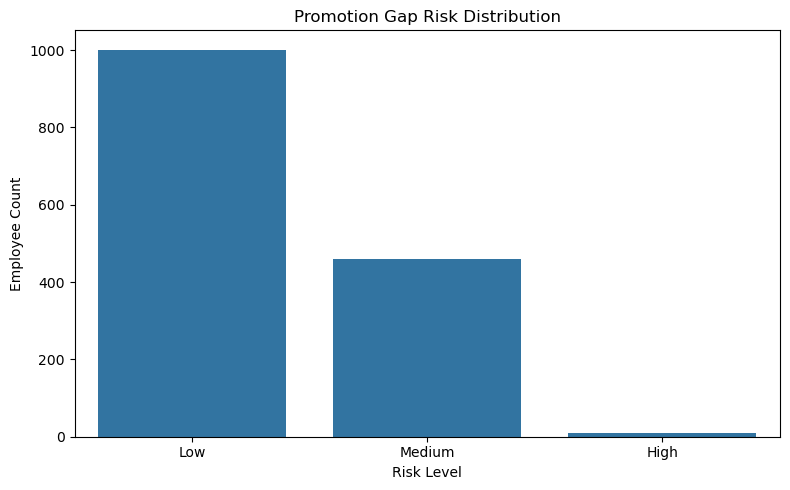

In [11]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="PromotionGapRiskLevel",
    order=["Low", "Medium", "High"]
)
plt.title("Promotion Gap Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Employee Count")
plt.tight_layout()
plt.savefig(FIGURES / "promotion_gap_risk_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()


# 12. High-Risk Employee Analysis

Focus on the employees with a High Promotion Gap Risk Level.

We will summarize their:

- Department
- Job role
- Job level
- Performance
- Satisfaction
- Training
- Attrition


In [12]:
high_risk = df[df["PromotionGapRiskLevel"] == "High"].copy()

print("High-risk employee count:", len(high_risk))

high_risk_summary = (
    high_risk["Department"]
    .value_counts()
    .rename_axis("Department")
    .reset_index(name="High_Risk_Employees")
)

display(high_risk_summary)
high_risk_summary.to_csv(
    TABLES / "high_risk_by_department.csv",
    index=False
)


High-risk employee count: 10


,Department,High_Risk_Employees
0,Research & Development,5
1,Sales,5


## 13. Department Risk Analysis


In [13]:
department_risk = (
    df.groupby("Department", observed=True)
      .agg(
          Employee_Count=("PromotionGapRiskLevel", "size"),
          High_Risk_Count=(
              "PromotionGapRiskLevel",
              lambda x: (x == "High").sum()
          )
      )
      .reset_index()
)

department_risk["High_Risk_Percentage"] = (
    department_risk["High_Risk_Count"]
    / department_risk["Employee_Count"]
    * 100
).round(2)

display(department_risk)

department_risk.to_csv(
    TABLES / "department_risk_summary.csv",
    index=False
)


,Department,Employee_Count,High_Risk_Count,High_Risk_Percentage
0,Human Resources,63,0,0.00
1,Research & Development,961,5,0.52
2,Sales,446,5,1.12


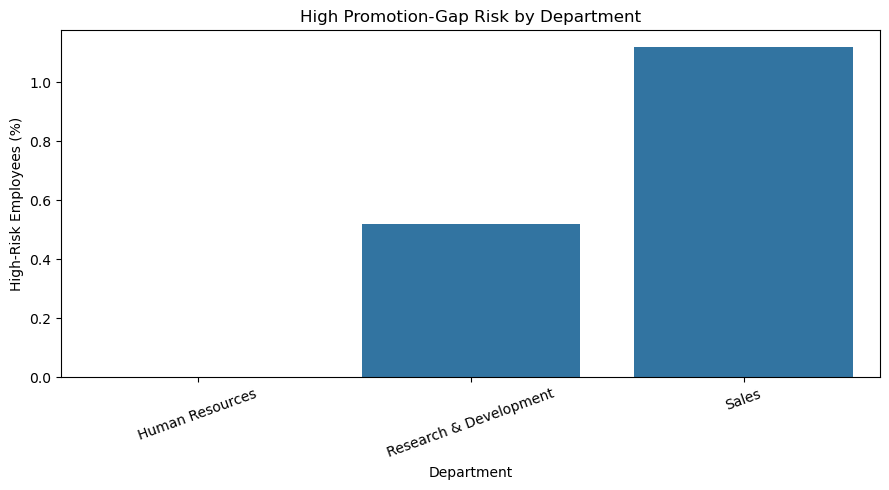

In [14]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=department_risk,
    x="Department",
    y="High_Risk_Percentage"
)
plt.title("High Promotion-Gap Risk by Department")
plt.xlabel("Department")
plt.ylabel("High-Risk Employees (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIGURES / "high_risk_by_department.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()


## 14. Job Role Risk Analysis


In [15]:
jobrole_risk = (
    df.groupby("JobRole", observed=True)
      .agg(
          Employee_Count=("PromotionGapRiskLevel", "size"),
          High_Risk_Count=(
              "PromotionGapRiskLevel",
              lambda x: (x == "High").sum()
          )
      )
      .reset_index()
)

jobrole_risk["High_Risk_Percentage"] = (
    jobrole_risk["High_Risk_Count"]
    / jobrole_risk["Employee_Count"]
    * 100
).round(2)

display(
    jobrole_risk.sort_values(
        "High_Risk_Percentage",
        ascending=False
    )
)

jobrole_risk.to_csv(
    TABLES / "jobrole_risk_summary.csv",
    index=False
)


,JobRole,Employee_Count,High_Risk_Count,High_Risk_Percentage
4,Manufacturing Director,145,2,1.38
5,Research Director,80,1,1.25
7,Sales Executive,326,4,1.23
3,Manager,102,1,0.98
0,Healthcare Representative,131,1,0.76
6,Research Scientist,292,1,0.34
1,Human Resources,52,0,0.00
2,Laboratory Technician,259,0,0.00
8,Sales Representative,83,0,0.00


## 15. Career Cluster + Risk

If Day 5 clusters are available, compare career clusters with the risk levels.


In [16]:
if "CareerCluster" in df.columns:
    cluster_risk = pd.crosstab(
        df["CareerCluster"],
        df["PromotionGapRiskLevel"],
        normalize="index"
    ).mul(100).round(2)

    display(cluster_risk)

    cluster_risk.to_csv(
        TABLES / "career_cluster_risk_percentage.csv"
    )
else:
    print("CareerCluster not available.")


CareerCluster not available.


In [17]:
if "CareerCluster" in df.columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(
        data=df,
        x="CareerCluster",
        hue="PromotionGapRiskLevel",
        hue_order=["Low", "Medium", "High"]
    )
    plt.title("Promotion Risk by Career Cluster")
    plt.xlabel("Career Cluster")
    plt.ylabel("Employee Count")
    plt.tight_layout()
    plt.savefig(FIGURES / "risk_by_career_cluster.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()


# 16. Retention Opportunity Index

### Business idea

A retention opportunity is different from simply saying an employee is likely to leave.

We want to identify employees who:

- Have meaningful career-stagnation signals
- Are still employed
- May benefit from proactive career-development action

For this dataset, `Attrition == "No"` means the employee is still with the company.

We will use the career-risk score as the primary opportunity signal and exclude employees who have already left.


In [18]:
df["RetentionOpportunityScore"] = np.where(
    df["Attrition"].eq("No"),
    df["PromotionGapRiskScore"],
    0
)

df["RetentionOpportunityLevel"] = pd.cut(
    df["RetentionOpportunityScore"],
    bins=[-1, 2, 5, 8],
    labels=["Low", "Medium", "High"]
)

retention_summary = (
    df["RetentionOpportunityLevel"]
    .value_counts(sort=False)
    .rename_axis("Opportunity_Level")
    .reset_index(name="Employee_Count")
)

retention_summary["Percentage"] = (
    retention_summary["Employee_Count"] / len(df) * 100
).round(2)

display(retention_summary)

retention_summary.to_csv(
    TABLES / "retention_opportunity_summary.csv",
    index=False
)


,Opportunity_Level,Employee_Count,Percentage
0,Low,1470,100.0
1,Medium,0,0.0
2,High,0,0.0


## 17. Retention Opportunity Visualization


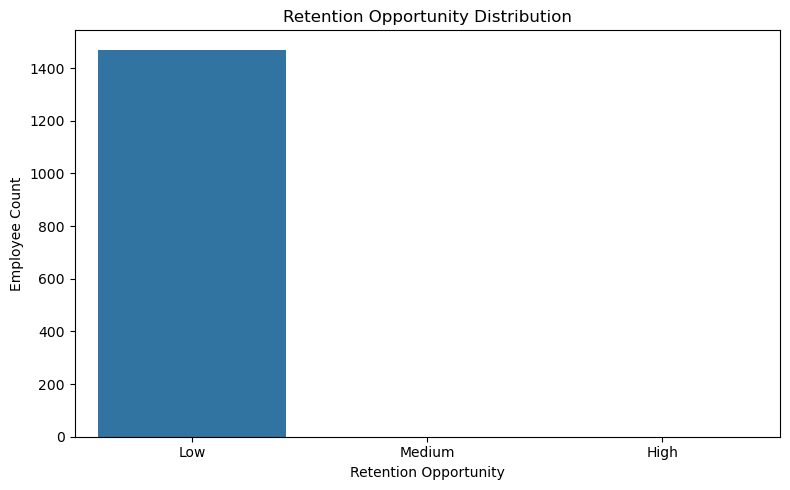

In [19]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="RetentionOpportunityLevel",
    order=["Low", "Medium", "High"]
)
plt.title("Retention Opportunity Distribution")
plt.xlabel("Retention Opportunity")
plt.ylabel("Employee Count")
plt.tight_layout()
plt.savefig(FIGURES / "retention_opportunity_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()


# 18. Recommended HR Action

Create an explainable action based on the strongest career-development signal.

Priority logic:

1. High promotion gap → Promotion Review
2. Long role duration → Career Development / Internal Mobility
3. No training → Training / Upskilling
4. Otherwise → Career Check-in
5. Low opportunity → No Immediate Action

The action is a recommendation for HR investigation, not an automated decision about an employee.


In [20]:
def recommend_action(row):
    if row["RetentionOpportunityLevel"] == "High":
        if row["YearsSinceLastPromotion"] >= 5:
            return "Promotion Review"
        elif row["YearsInCurrentRole"] >= 6:
            return "Career Development / Internal Mobility"
        elif row["TrainingTimesLastYear"] == 0:
            return "Training / Upskilling"
        else:
            return "Career Development Discussion"

    if row["RetentionOpportunityLevel"] == "Medium":
        if row["TrainingTimesLastYear"] == 0:
            return "Training / Upskilling"
        elif row["YearsSinceLastPromotion"] >= 2:
            return "Career Check-in"
        else:
            return "Monitor Career Progression"

    return "No Immediate Action"

df["RecommendedAction"] = df.apply(recommend_action, axis=1)

display(
    df[
        [
            "PromotionGapRiskLevel",
            "RetentionOpportunityLevel",
            "RecommendedAction"
        ]
    ].head(10)
)


,PromotionGapRiskLevel,RetentionOpportunityLevel,RecommendedAction
0,Medium,Low,No Immediate Action
1,Low,Low,No Immediate Action
2,Low,Low,No Immediate Action
3,Medium,Low,No Immediate Action
4,Low,Low,No Immediate Action
5,Medium,Low,No Immediate Action
6,Low,Low,No Immediate Action
7,Low,Low,No Immediate Action
8,Medium,Low,No Immediate Action
9,Medium,Low,No Immediate Action


## 19. Attrition Validation

Now compare career-risk levels with observed attrition.

This is **validation/association analysis**, not proof that the risk score causes attrition.


In [21]:
risk_attrition = (
    df.groupby("PromotionGapRiskLevel", observed=False)
      .agg(
          Employee_Count=("Attrition", "size"),
          Attrition_Count=("Attrition", lambda x: (x == "Yes").sum())
      )
      .reset_index()
)

risk_attrition["Attrition_Rate"] = (
    risk_attrition["Attrition_Count"]
    / risk_attrition["Employee_Count"]
    * 100
).round(2)

display(risk_attrition)

risk_attrition.to_csv(
    TABLES / "risk_vs_attrition.csv",
    index=False
)


,PromotionGapRiskLevel,Employee_Count,Attrition_Count,Attrition_Rate
0,Low,1001,0,0.0
1,Medium,459,0,0.0
2,High,10,0,0.0


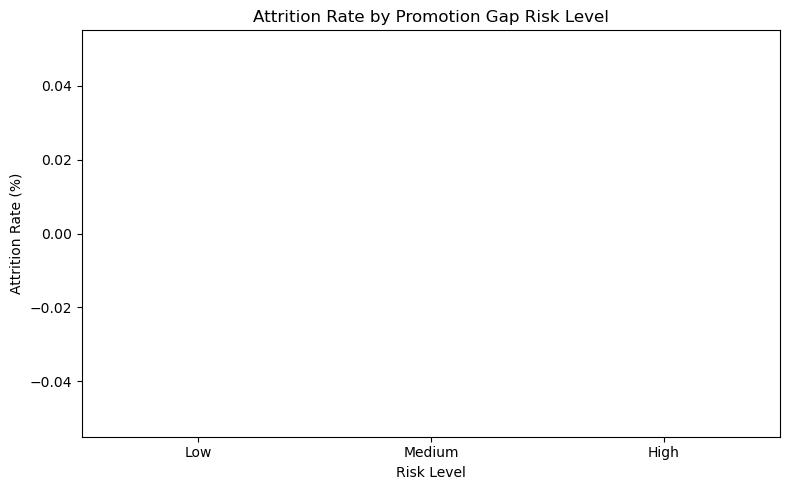

In [22]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=risk_attrition,
    x="PromotionGapRiskLevel",
    y="Attrition_Rate",
    order=["Low", "Medium", "High"]
)
plt.title("Attrition Rate by Promotion Gap Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Attrition Rate (%)")
plt.tight_layout()
plt.savefig(FIGURES / "risk_vs_attrition.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()


# 20. Statistical Validation — Chi-Square Test

Test whether `PromotionGapRiskLevel` and `Attrition` are statistically associated.

### Hypotheses

**H0:** Risk level and attrition are independent.

**H1:** Risk level and attrition are associated.

We use a significance level of 0.05.

> Statistical association does not establish causation.


In [23]:
contingency_table = pd.crosstab(
    df["PromotionGapRiskLevel"],
    df["Attrition"]
)

display(contingency_table)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

chi_square_result = pd.DataFrame({
    "Chi2": [chi2],
    "Degrees_of_Freedom": [dof],
    "P_Value": [p_value],
    "Significance_Level": [0.05],
    "Conclusion": [
        "Evidence of association"
        if p_value < 0.05
        else "Insufficient evidence of association"
    ]
})

display(chi_square_result)

chi_square_result.to_csv(
    TABLES / "chi_square_risk_attrition.csv",
    index=False
)


Attrition,0,1
PromotionGapRiskLevel,,
Low,823,178
Medium,403,56
High,7,3


,Chi2,Degrees_of_Freedom,P_Value,Significance_Level,Conclusion
0,8.684298,2,0.013009,0.05,Evidence of association


# 21. Employee-Level Retention Opportunity Output

Create a practical table for HR analysis.

We avoid using unnecessary columns and keep the output focused on career-development signals.


In [24]:
employee_output_columns = [
    "EmployeeNumber",
    "Department",
    "JobRole",
    "JobLevel",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager",
    "TrainingTimesLastYear",
    "PerformanceRating",
    "JobSatisfaction",
    "CareerCluster",
    "PromotionGapRiskScore",
    "PromotionGapRiskLevel",
    "RetentionOpportunityScore",
    "RetentionOpportunityLevel",
    "RecommendedAction",
    "Attrition"
]

employee_output_columns = [
    col for col in employee_output_columns
    if col in df.columns
]

employee_output = df[employee_output_columns].copy()

display(employee_output.head(10))

employee_output.to_csv(
    TABLES / "employee_retention_opportunity.csv",
    index=False
)


,Department,JobRole,JobLevel,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,TrainingTimesLastYear,PerformanceRating,JobSatisfaction,PromotionGapRiskScore,PromotionGapRiskLevel,RetentionOpportunityScore,RetentionOpportunityLevel,RecommendedAction,Attrition
0,Sales,Sales Executive,2,6,4,0,5,0,3,4,3,Medium,0,Low,No Immediate Action,1
1,Research & Development,Research Scientist,2,10,7,1,7,3,4,2,2,Low,0,Low,No Immediate Action,0
2,Research & Development,Laboratory Technician,1,0,0,0,0,3,3,3,0,Low,0,Low,No Immediate Action,1
3,Research & Development,Research Scientist,1,8,7,3,0,3,3,3,3,Medium,0,Low,No Immediate Action,0
4,Research & Development,Laboratory Technician,1,2,2,2,2,3,3,2,1,Low,0,Low,No Immediate Action,0
5,Research & Development,Laboratory Technician,1,7,7,3,6,2,3,4,4,Medium,0,Low,No Immediate Action,0
6,Research & Development,Laboratory Technician,1,1,0,0,0,3,4,1,0,Low,0,Low,No Immediate Action,0
7,Research & Development,Laboratory Technician,1,1,0,0,0,2,4,3,1,Low,0,Low,No Immediate Action,0
8,Research & Development,Manufacturing Director,3,9,7,1,8,2,4,3,3,Medium,0,Low,No Immediate Action,0
9,Research & Development,Healthcare Representative,2,7,7,7,7,3,3,3,4,Medium,0,Low,No Immediate Action,0


## 22. High Retention Opportunity Employees

These are current employees with the highest career-development opportunity score.

Sort by score first, then by promotion gap.


In [25]:
high_opportunity = (
    df[
        (df["Attrition"] == "No")
        & (df["RetentionOpportunityLevel"] == "High")
    ]
    .sort_values(
        ["RetentionOpportunityScore", "YearsSinceLastPromotion"],
        ascending=[False, False]
    )
    .copy()
)

display(
    high_opportunity[
        [
            col for col in [
                "EmployeeNumber",
                "Department",
                "JobRole",
                "JobLevel",
                "YearsAtCompany",
                "YearsInCurrentRole",
                "YearsSinceLastPromotion",
                "TrainingTimesLastYear",
                "PromotionGapRiskScore",
                "RetentionOpportunityLevel",
                "RecommendedAction"
            ]
            if col in high_opportunity.columns
        ]
    ].head(20)
)

high_opportunity.to_csv(
    TABLES / "high_retention_opportunity_employees.csv",
    index=False
)


,Department,JobRole,JobLevel,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,TrainingTimesLastYear,PromotionGapRiskScore,RetentionOpportunityLevel,RecommendedAction


# 23. Executive Summary Tables

Create compact tables for the future dashboard/report.


In [26]:
executive_summary = {
    "Total Employees": len(df),
    "High Promotion Risk Employees": int(
        (df["PromotionGapRiskLevel"] == "High").sum()
    ),
    "High Promotion Risk %": round(
        (df["PromotionGapRiskLevel"] == "High").mean() * 100, 2
    ),
    "High Retention Opportunity Employees": int(
        (df["RetentionOpportunityLevel"] == "High").sum()
    ),
    "High Retention Opportunity %": round(
        (df["RetentionOpportunityLevel"] == "High").mean() * 100, 2
    ),
    "Observed Attrition Rate %": round(
        (df["Attrition"] == "Yes").mean() * 100, 2
    )
}

executive_summary_df = pd.DataFrame(
    executive_summary.items(),
    columns=["Metric", "Value"]
)

display(executive_summary_df)

executive_summary_df.to_csv(
    TABLES / "executive_summary.csv",
    index=False
)


,Metric,Value
0,Total Employees,1470.00
1,High Promotion Risk Employees,10.00
2,High Promotion Risk %,0.68
3,High Retention Opportunity Employees,0.00
4,High Retention Opportunity %,0.00
5,Observed Attrition Rate %,0.00


# 24. Automatically Generate Text Report

This report summarizes the main Day 6 outputs and is saved automatically in `outputs/reports/`.


In [27]:
report_lines = []

report_lines.append("# Day 6 — Promotion Gap Risk & Retention Opportunity Report")
report_lines.append("")
report_lines.append("## Executive Summary")
for metric, value in executive_summary.items():
    report_lines.append(f"- {metric}: {value}")

report_lines.append("")
report_lines.append("## Risk Distribution")
for _, row in risk_summary.iterrows():
    report_lines.append(
        f"- {row['Risk_Level']}: {row['Employee_Count']} employees "
        f"({row['Percentage']}%)"
    )

report_lines.append("")
report_lines.append("## Department Risk")
for _, row in department_risk.sort_values(
    "High_Risk_Percentage", ascending=False
).iterrows():
    report_lines.append(
        f"- {row['Department']}: {row['High_Risk_Count']} high-risk employees "
        f"out of {row['Employee_Count']} "
        f"({row['High_Risk_Percentage']}%)"
    )

report_lines.append("")
report_lines.append("## Attrition Validation")
report_lines.append(
    f"- Chi-square p-value: {p_value:.6f}"
)
report_lines.append(
    f"- Conclusion: {chi_square_result.loc[0, 'Conclusion']}"
)

report_lines.append("")
report_lines.append("## Important Interpretation")
report_lines.append(
    "- The risk and opportunity scores are explainable decision-support indicators."
)
report_lines.append(
    "- They do not prove that an employee will leave."
)
report_lines.append(
    "- High career-risk employees should be reviewed by HR using additional context."
)
report_lines.append(
    "- Statistical association does not establish causation."
)

report_path = REPORTS / "day6_risk_retention_report.md"
report_path.write_text("\n".join(report_lines), encoding="utf-8")

print(f"Report saved to: {report_path}")


Report saved to: ../outputs/reports/day6_risk_retention_report.md


# 25. Save Final Day 6 Dataset

This file will be used by the dashboard and later project stages.

Output:

`data/hr_career_risk_analysis.csv`


In [28]:
final_data_path = PROJECT_ROOT / "data" / "hr_career_risk_analysis.csv"

df.to_csv(final_data_path, index=False)

print(f"Final Day 6 dataset saved to: {final_data_path}")


Final Day 6 dataset saved to: ../data/hr_career_risk_analysis.csv


In [32]:
import streamlit as st


In [33]:
st.title("hello world")

2026-08-31 17:16:54.922 
  command:

    streamlit run /home/pratik/anaconda3/lib/python3.12/site-packages/ipykernel_launcher.py [ARGUMENTS]


DeltaGenerator()